In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import os, joblib, warnings
from google.colab import files
warnings.filterwarnings("ignore")

for d in ["data", "images", "models"]:
    os.makedirs(d, exist_ok=True)

up = files.upload()
for f in up: os.replace(f, f"data/{f}")
df = pd.read_csv("data/DS_Day01_37_Digital_Marketing_Dataset.csv")
print(df.shape); df.head()

Saving DS_Day01_37_Digital_Marketing_Dataset.csv to DS_Day01_37_Digital_Marketing_Dataset.csv
(608, 7)


,Campaign_ID,Customer_Segment,Campaign_Cost,Impressions,Clicks,Conversions,Revenue
0,CMP01,Seniors,15244.43,500227.0,26609.0,963.0,80793.62
1,CMP02,Young Professionals,13875.17,602762.0,53060.0,297.0,20269.82
2,CMP01,Students,-8780.37,202365.0,9386.0,455.0,28478.33
3,CMP03,Families,1347.36,77799.0,2758.0,291.0,35630.74
4,CMP05,Students,14598.90,237950.0,7737.0,51.0,3645.83


In [2]:
print(df.isna().sum())
print("Duplicate rows:", df.duplicated().sum())
print(df.Customer_Segment.value_counts(dropna=False))
print("Negative cost:", (df.Campaign_Cost < 0).sum())
print("Clicks > Impressions:", (df.Clicks > df.Impressions).sum())
print("Conversions > Clicks:", (df.Conversions > df.Clicks).sum())

Campaign_ID         0
Customer_Segment    3
Campaign_Cost       4
Impressions         3
Clicks              4
Conversions         3
Revenue             5
dtype: int64
Duplicate rows: 8
Customer_Segment
Seniors                128
Young Professionals    125
Students               121
Families               114
Premium Customers      105
 Seniors                 3
seniors                  3
NaN                      3
 Premium Customers       2
students                 1
 Families                1
families                 1
young professionals      1
Name: count, dtype: int64
Negative cost: 2
Clicks > Impressions: 4
Conversions > Clicks: 3


In [3]:
num = ["Campaign_Cost","Impressions","Clicks","Conversions","Revenue"]

df = df.drop_duplicates()
df["Customer_Segment"] = df.Customer_Segment.str.strip().str.title()

# fix invalid values
df.loc[df.Campaign_Cost < 0, "Campaign_Cost"] = df.Campaign_Cost.abs()
df.loc[df.Clicks > df.Impressions, "Clicks"] = np.nan
df.loc[df.Conversions > df.Clicks, "Conversions"] = np.nan

# fill missing values with each campaign's median
for c in num:
    df[c] = df[c].fillna(df.groupby("Campaign_ID")[c].transform("median"))
df["Customer_Segment"] = df.Customer_Segment.fillna(df.Customer_Segment.mode()[0])

# revenue outliers: replace extreme values with the campaign median
g_ = df.groupby("Campaign_ID")
q1 = g_.Revenue.transform(lambda s: s.quantile(.25))
q3 = g_.Revenue.transform(lambda s: s.quantile(.75))
out = df.Revenue > q3 + 3*(q3 - q1)
print("Revenue outliers fixed:", out.sum())
df.loc[out, "Revenue"] = g_.Revenue.transform("median")

print("Missing left:", df.isna().sum().sum(), "| Shape:", df.shape)

Revenue outliers fixed: 12
Missing left: 0 | Shape: (600, 7)


In [4]:
df["CTR"]  = df.Clicks / df.Impressions * 100          # click-through rate %
df["CVR"]  = df.Conversions / df.Clicks * 100          # conversion rate %
df["CPA"]  = df.Campaign_Cost / df.Conversions.replace(0, np.nan)   # cost per acquisition
df["ROAS"] = df.Revenue / df.Campaign_Cost             # return on ad spend
df.to_csv("data/marketing_cleaned.csv", index=False)
display(df.describe().T.round(2))

,count,mean,std,min,25%,50%,75%,max
Campaign_Cost,600.0,11014.99,5776.57,800.00,6345.92,10782.87,14970.90,30631.78
Impressions,600.0,495126.23,473971.57,33030.00,202462.50,309760.00,511304.50,2846978.00
Clicks,600.0,13875.49,10275.85,1590.00,7383.75,10593.00,16790.75,66670.00
Conversions,600.0,370.50,263.76,21.00,186.00,298.00,485.00,1727.00
Revenue,600.0,33202.13,28639.33,1037.67,12649.08,24335.14,43949.24,165672.68
CTR,600.0,4.11,2.62,0.40,2.40,3.72,5.06,11.24
CVR,600.0,3.86,3.11,0.11,1.26,2.66,6.21,16.77
CPA,600.0,53.56,63.29,2.30,13.38,38.84,70.99,832.40
ROAS,600.0,4.90,6.03,0.07,0.96,2.36,6.56,48.12


In [5]:
g = df.groupby("Campaign_ID")[num].sum()
g["CTR"]  = g.Clicks / g.Impressions * 100
g["CVR"]  = g.Conversions / g.Clicks * 100
g["CPA"]  = g.Campaign_Cost / g.Conversions
g["ROAS"] = g.Revenue / g.Campaign_Cost
g["Profit"] = g.Revenue - g.Campaign_Cost
g["Spend_share%"]   = g.Campaign_Cost / g.Campaign_Cost.sum() * 100
g["Revenue_share%"] = g.Revenue / g.Revenue.sum() * 100
display(g.round(2))
g.round(2).to_csv("data/campaign_summary.csv")

,Campaign_Cost,Impressions,Clicks,Conversions,Revenue,CTR,CVR,CPA,ROAS,Profit,Spend_share%,Revenue_share%
Campaign_ID,,,,,,,,,,,,
CMP01,1069147.93,28909205.0,1291407.0,74552.0,7043785.68,4.47,5.77,14.34,6.59,5974637.75,16.18,35.36
CMP02,1236255.41,42047770.0,3561505.0,26291.0,1742928.90,8.47,0.74,47.02,1.41,506673.49,18.71,8.75
CMP03,404042.40,18965297.0,718965.0,61273.0,5263256.58,3.79,8.52,6.59,13.03,4859214.18,6.11,26.42
CMP04,1834493.90,158544644.0,1282701.0,24539.0,1729780.02,0.81,1.91,74.76,0.94,-104713.88,27.76,8.68
CMP05,2065055.15,48608823.0,1470717.0,35647.0,4141527.97,3.03,2.42,57.93,2.01,2076472.82,31.25,20.79


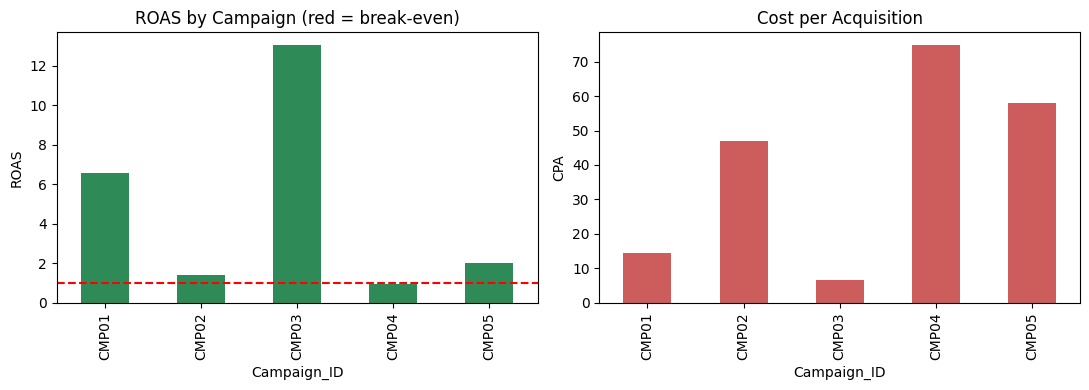

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
g.ROAS.plot.bar(ax=ax[0], color="seagreen"); ax[0].axhline(1, color="red", ls="--")
ax[0].set_title("ROAS by Campaign (red = break-even)"); ax[0].set_ylabel("ROAS")
g.CPA.plot.bar(ax=ax[1], color="indianred"); ax[1].set_title("Cost per Acquisition"); ax[1].set_ylabel("CPA")
plt.tight_layout(); plt.savefig("images/1_campaign_roas_cpa.png", dpi=150); plt.show()

In [7]:
print("Row-level correlation CTR vs Revenue:", round(df.CTR.corr(df.Revenue), 3))
print("Row-level correlation CTR vs ROAS   :", round(df.CTR.corr(df.ROAS), 3))
display(g[["CTR","CVR","ROAS"]].sort_values("CTR", ascending=False).round(2))

Row-level correlation CTR vs Revenue: 0.007
Row-level correlation CTR vs ROAS   : 0.014


,CTR,CVR,ROAS
Campaign_ID,,,
CMP02,8.47,0.74,1.41
CMP01,4.47,5.77,6.59
CMP03,3.79,8.52,13.03
CMP05,3.03,2.42,2.01
CMP04,0.81,1.91,0.94


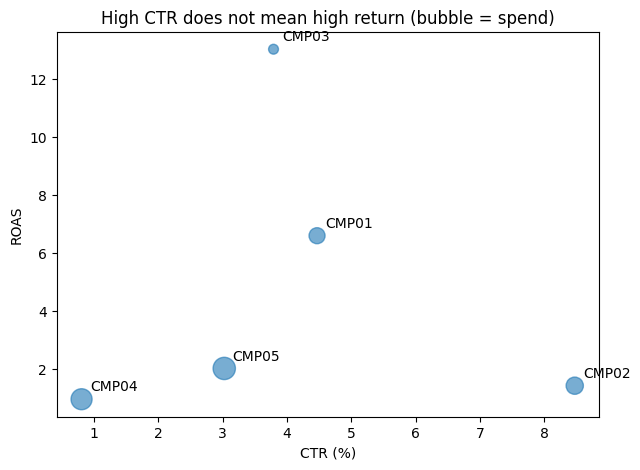

In [8]:
plt.figure(figsize=(7, 5))
plt.scatter(g.CTR, g.ROAS, s=g.Campaign_Cost/8000, alpha=.6)
for i, r in g.iterrows():
    plt.annotate(i, (r.CTR, r.ROAS), xytext=(6, 6), textcoords="offset points")
plt.xlabel("CTR (%)"); plt.ylabel("ROAS"); plt.title("High CTR does not mean high return (bubble = spend)")
plt.savefig("images/2_ctr_vs_roas.png", dpi=150, bbox_inches="tight"); plt.show()

In [9]:
s = df.groupby("Customer_Segment")[num].sum()
s["ROAS"] = s.Revenue / s.Campaign_Cost
s["CVR"]  = s.Conversions / s.Clicks * 100
s["CPA"]  = s.Campaign_Cost / s.Conversions
display(s.round(2).sort_values("ROAS", ascending=False))

pv = df.pivot_table(index="Campaign_ID", columns="Customer_Segment",
                    values=["Revenue","Campaign_Cost"], aggfunc="sum")
hm = pv["Revenue"] / pv["Campaign_Cost"]

,Campaign_Cost,Impressions,Clicks,Conversions,Revenue,ROAS,CVR,CPA
Customer_Segment,,,,,,,,
Premium Customers,1132758.70,54881819.5,1534409.0,45376.0,5597992.30,4.94,2.96,24.96
Young Professionals,1360425.22,65695888.0,1676145.0,50996.0,4321683.70,3.18,3.04,26.68
Families,1255873.77,58879166.0,1559018.0,42666.0,3946162.76,3.14,2.74,29.44
Seniors,1507944.80,62108230.5,1906681.0,47117.0,3694103.84,2.45,2.47,32.00
Students,1351992.30,55510635.0,1649042.0,36147.0,2361336.55,1.75,2.19,37.40


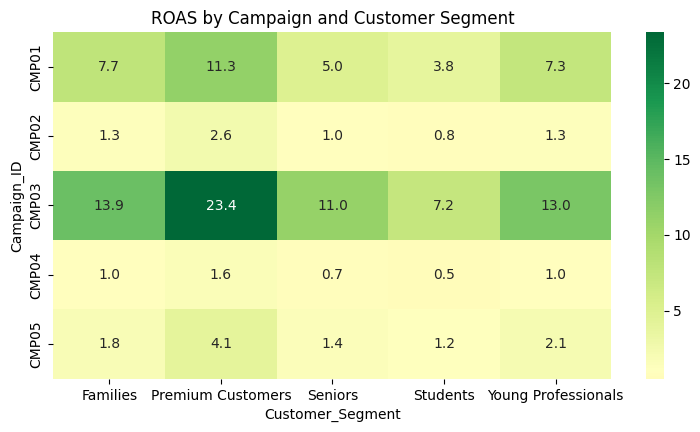

In [10]:
plt.figure(figsize=(9, 4.5))
sns.heatmap(hm, annot=True, fmt=".1f", cmap="RdYlGn", center=1)
plt.title("ROAS by Campaign and Customer Segment")
plt.savefig("images/3_segment_campaign_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

In [11]:
high_cost = df.Campaign_Cost > df.Campaign_Cost.quantile(.75)   # top 25% by spend
low_roas  = df.ROAS < 1                                          # losing money
df["Flag"] = np.where(high_cost & low_roas, "High cost, low impact", "Other")

print("High-cost rows:", high_cost.sum(), "| of which ROAS < 1:", (high_cost & low_roas).sum())
print(df[high_cost & low_roas].groupby("Campaign_ID").size())
print("Share of each campaign's spend on ROAS<1 records:")
print((df[low_roas].groupby("Campaign_ID").Campaign_Cost.sum() /
       df.groupby("Campaign_ID").Campaign_Cost.sum()).round(2))

High-cost rows: 150 | of which ROAS < 1: 72
Campaign_ID
CMP02     5
CMP04    44
CMP05    23
dtype: int64
Share of each campaign's spend on ROAS<1 records:
Campaign_ID
CMP01     NaN
CMP02    0.42
CMP03     NaN
CMP04    0.66
CMP05    0.28
Name: Campaign_Cost, dtype: float64


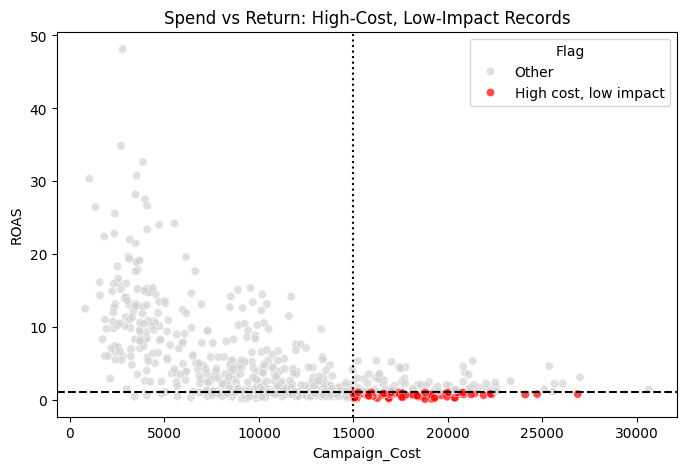

In [12]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Campaign_Cost", y="ROAS", hue="Flag", alpha=.7,
                palette={"High cost, low impact": "red", "Other": "lightgrey"})
plt.axhline(1, color="black", ls="--"); plt.axvline(df.Campaign_Cost.quantile(.75), color="black", ls=":")
plt.title("Spend vs Return: High-Cost, Low-Impact Records")
plt.savefig("images/4_high_cost_low_impact.png", dpi=150, bbox_inches="tight"); plt.show()

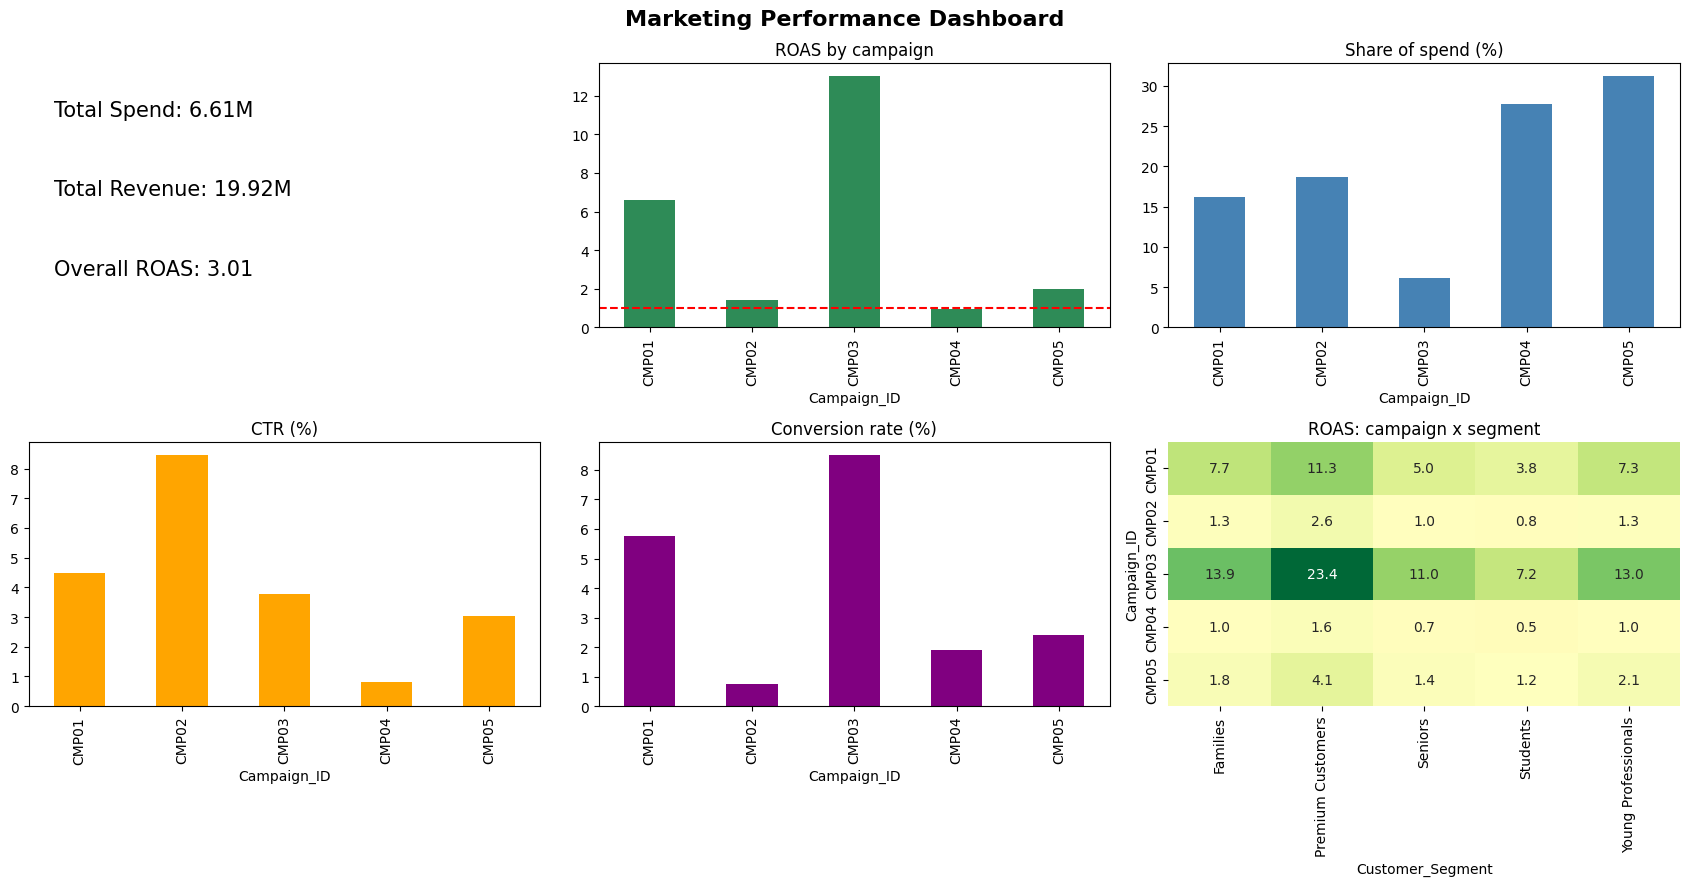

In [13]:
fig, ax = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle("Marketing Performance Dashboard", fontsize=16, fontweight="bold")
ax[0,0].axis("off")
kpis = [("Total Spend", f"{df.Campaign_Cost.sum()/1e6:.2f}M"),
        ("Total Revenue", f"{df.Revenue.sum()/1e6:.2f}M"),
        ("Overall ROAS", f"{df.Revenue.sum()/df.Campaign_Cost.sum():.2f}")]
for i, (a, b) in enumerate(kpis): ax[0,0].text(0.05, 0.8 - i*0.3, f"{a}: {b}", fontsize=15)
g.ROAS.plot.bar(ax=ax[0,1], color="seagreen", title="ROAS by campaign"); ax[0,1].axhline(1, color="red", ls="--")
g["Spend_share%"].plot.bar(ax=ax[0,2], color="steelblue", title="Share of spend (%)")
g.CTR.plot.bar(ax=ax[1,0], color="orange", title="CTR (%)")
g.CVR.plot.bar(ax=ax[1,1], color="purple", title="Conversion rate (%)")
sns.heatmap(hm, annot=True, fmt=".1f", cmap="RdYlGn", center=1, ax=ax[1,2], cbar=False)
ax[1,2].set_title("ROAS: campaign x segment")
plt.tight_layout(); plt.savefig("images/5_marketing_dashboard.png", dpi=130); plt.show()

In [14]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay

df["High_ROAS"] = (df.ROAS >= df.ROAS.median()).astype(int)
X = pd.get_dummies(df[["Customer_Segment","Campaign_Cost","Impressions","CTR","CVR"]],
                   columns=["Customer_Segment"])
y = df.High_ROAS
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, stratify=y, random_state=42)

dt = DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=42).fit(X_train, y_train)

In [15]:
report = classification_report(y_test, dt.predict(X_test), target_names=["Low ROAS","High ROAS"])
auc = roc_auc_score(y_test, dt.predict_proba(X_test)[:,1])
cv  = cross_val_score(dt, X, y, cv=5).mean()
print(report); print("ROC-AUC:", round(auc, 3)); print("5-fold CV accuracy:", round(cv, 3))

imp = pd.Series(dt.feature_importances_, X.columns).sort_values(ascending=False)
print(imp.round(3).head(6))

              precision    recall  f1-score   support

    Low ROAS       0.94      0.97      0.95        60
   High ROAS       0.97      0.93      0.95        60

    accuracy                           0.95       120
   macro avg       0.95      0.95      0.95       120
weighted avg       0.95      0.95      0.95       120

ROC-AUC: 0.983
5-fold CV accuracy: 0.923
CVR                                   0.864
Impressions                           0.073
Customer_Segment_Premium Customers    0.039
CTR                                   0.024
Campaign_Cost                         0.000
Customer_Segment_Families             0.000
dtype: float64


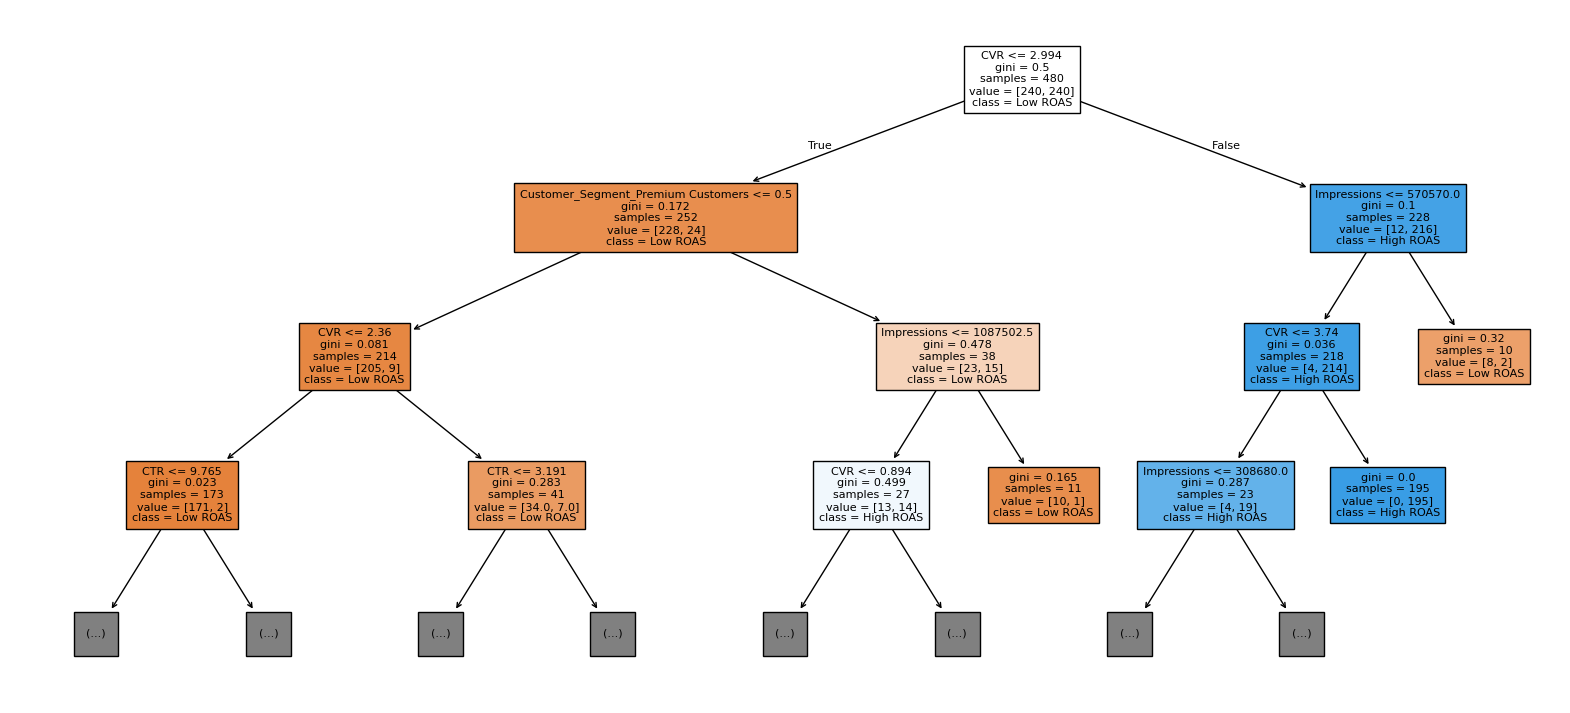

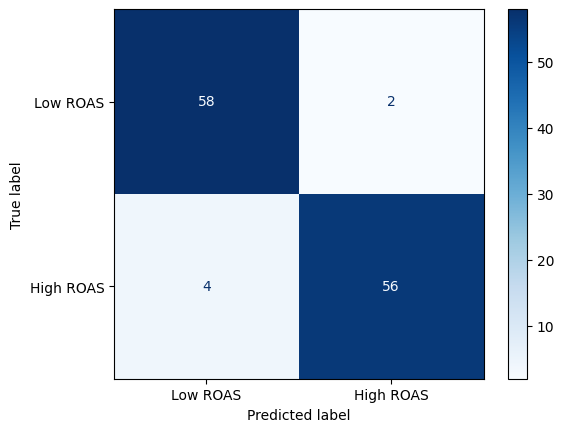

In [16]:
plt.figure(figsize=(20, 9))
plot_tree(dt, feature_names=X.columns, class_names=["Low ROAS","High ROAS"], filled=True, fontsize=8, max_depth=3)
plt.savefig("images/6_decision_tree.png", dpi=130, bbox_inches="tight"); plt.show()

ConfusionMatrixDisplay.from_estimator(dt, X_test, y_test, display_labels=["Low ROAS","High ROAS"], cmap="Blues")
plt.savefig("images/7_confusion_matrix.png", dpi=150); plt.show()

joblib.dump(dt, "models/decision_tree.pkl")
with open("models/metrics.txt", "w") as f:
    f.write(report + f"\nROC-AUC: {auc:.3f}\n5-fold CV accuracy: {cv:.3f}\n\nFeature importance:\n" + imp.round(3).to_string())

In [17]:
!zip -r project_files.zip data images models
files.download("project_files.zip")

  adding: data/ (stored 0%)
  adding: data/DS_Day01_37_Digital_Marketing_Dataset.csv (deflated 62%)
  adding: data/campaign_summary.csv (deflated 39%)
  adding: data/marketing_cleaned.csv (deflated 55%)
  adding: images/ (stored 0%)
  adding: images/5_marketing_dashboard.png (deflated 19%)
  adding: images/4_high_cost_low_impact.png (deflated 7%)
  adding: images/2_ctr_vs_roas.png (deflated 17%)
  adding: images/7_confusion_matrix.png (deflated 21%)
  adding: images/1_campaign_roas_cpa.png (deflated 22%)
  adding: images/6_decision_tree.png (deflated 9%)
  adding: images/3_segment_campaign_heatmap.png (deflated 10%)
  adding: models/ (stored 0%)
  adding: models/metrics.txt (deflated 65%)
  adding: models/decision_tree.pkl (deflated 54%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>